# Retail Sales Performance Analysis

## Step 1 - import libraries

In [2]:
import pandas as pd
import numpy as np

## Step 2 - load the RAW copy

In [3]:
df = pd.read_csv("D:\Projects\Retails_Sales_Performance_Analysis\Dataset\Retail_Sales_Performance_RAW.csv")
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Segment,Region,State,City,Product_ID,...,Quantity,Unit_Price,Discount_Percent,Sales,Cost,Profit,Ship_Mode,Payment_Method,Customer_Rating,Return_Status
0,ORD114403,11/07/2023,2023-07-19,CUST01227,Customer_01227,Corporate,North,Punjab,Amritsar,PRD01137,...,7,55942.02,25.0,293695.60,263633.02,30062.58,Express,NaN,5.0,Not Returned
1,ORD110963,02-11-2023,2023-02-20,CUST06270,Customer_06270,Corporate,North,Haryana,Faridabad,PRD01264,...,5,12184.17,30.0,42644.59,36445.92,6198.67,Same Day,Cash on Delivery,2.0,Not Returned
2,ORD104278,2024-08-13,2024-08-15,CUST10300,Customer_10300,Home Office,West,Maharashtra,Nagpur,PRD00479,...,1,5094.76,30.0,3566.33,2437.25,1129.08,Standard,UPI,2.0,Not Returned
3,ORD131584,2024-08-30,2024-09-01,CUST00217,Customer_00217,Home Office,West,Gujarat,Surat,PRD01925,...,8,21923.33,10.0,157847.98,129692.53,28155.45,Express,Debit Card,5.0,Returned
4,ORD100023,16/08/2023,2023-08-20,CUST05001,Customer_05001,Consumer,North,Rajasthan,Udaipur,PRD00097,...,7,30381.43,15.0,180769.51,146099.64,34669.87,Same Day,Debit Card,5.0,Not Returned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50295,ORD142697,18-01-2023,2023-01-28,CUST06667,Customer_06667,Corporate,East,West Bengal,Kolkata,PRD00342,...,6,161.05,5.0,917.99,680.52,237.47,Same Day,debit card,5.0,Not Returned
50296,ORD136008,12-09-2023,2023-12-11,CUST06089,Customer_06089,Corporate,North,Rajasthan,Udaipur,PRD01135,...,2,13079.03,0.0,26158.06,21276.47,4881.59,Express,Debit Card,5.0,Returned
50297,ORD146265,20/01/2023,2023-01-25,CUST05898,Customer_05898,Home Office,North,Rajasthan,Jaipur,PRD01820,...,2,6972.41,0.0,13944.82,11476.04,2468.78,Same Day,CREDIT CARD,5.0,Returned
50298,ORD123587,02-04-2024,2024-04-04,CUST00569,Customer_00569,Consumer,South,Tamil Nadu,Chennai,PRD01567,...,2,39845.59,30.0,55783.83,47576.03,8207.80,Express,UPI,5.0,Not Returned


In [4]:
    df = df.copy()

In [5]:
df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Segment,Region,State,City,Product_ID,...,Quantity,Unit_Price,Discount_Percent,Sales,Cost,Profit,Ship_Mode,Payment_Method,Customer_Rating,Return_Status
0,ORD114403,11/07/2023,2023-07-19,CUST01227,Customer_01227,Corporate,North,Punjab,Amritsar,PRD01137,...,7,55942.02,25.0,293695.60,263633.02,30062.58,Express,NaN,5.0,Not Returned
1,ORD110963,02-11-2023,2023-02-20,CUST06270,Customer_06270,Corporate,North,Haryana,Faridabad,PRD01264,...,5,12184.17,30.0,42644.59,36445.92,6198.67,Same Day,Cash on Delivery,2.0,Not Returned
2,ORD104278,2024-08-13,2024-08-15,CUST10300,Customer_10300,Home Office,West,Maharashtra,Nagpur,PRD00479,...,1,5094.76,30.0,3566.33,2437.25,1129.08,Standard,UPI,2.0,Not Returned
3,ORD131584,2024-08-30,2024-09-01,CUST00217,Customer_00217,Home Office,West,Gujarat,Surat,PRD01925,...,8,21923.33,10.0,157847.98,129692.53,28155.45,Express,Debit Card,5.0,Returned
4,ORD100023,16/08/2023,2023-08-20,CUST05001,Customer_05001,Consumer,North,Rajasthan,Udaipur,PRD00097,...,7,30381.43,15.0,180769.51,146099.64,34669.87,Same Day,Debit Card,5.0,Not Returned


## Step 3 - inital exploration

In [6]:
df.shape

(50300, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50300 entries, 0 to 50299
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          50300 non-null  object 
 1   Order_Date        50300 non-null  object 
 2   Ship_Date         49898 non-null  object 
 3   Customer_ID       50300 non-null  object 
 4   Customer_Name     49995 non-null  object 
 5   Segment           50300 non-null  object 
 6   Region            50300 non-null  object 
 7   State             50300 non-null  object 
 8   City              50149 non-null  object 
 9   Product_ID        50300 non-null  object 
 10  Category          50300 non-null  object 
 11  Sub_Category      50099 non-null  object 
 12  Quantity          50300 non-null  int64  
 13  Unit_Price        50300 non-null  float64
 14  Discount_Percent  50048 non-null  float64
 15  Sales             50300 non-null  float64
 16  Cost              50300 non-null  float6

In [8]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Sales,Cost,Profit,Customer_Rating
count,50300.000000,50300.000000,50048.000000,50300.000000,50300.000000,50300.000000,48794.000000
mean,4.512763,13649.160953,11.733336,54660.376833,43985.788376,10674.588457,3.373079
std,2.292862,20215.373502,11.063390,95695.931889,79773.813467,16863.490470,1.318909
min,-8.000000,100.050000,0.000000,81.770000,74.420000,5.150000,1.000000
25%,3.000000,1112.382500,0.000000,3742.472500,2837.960000,795.882500,2.000000
50%,5.000000,3416.305000,10.000000,12714.990000,8856.955000,3559.720000,3.000000
75%,6.000000,16546.282500,20.000000,58806.450000,45549.525000,12528.117500,5.000000
max,8.000000,89999.670000,150.000000,719006.960000,640518.750000,146213.040000,5.000000


In [10]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Ship_Date            402
Customer_ID            0
Customer_Name        305
Segment                0
Region                 0
State                  0
City                 151
Product_ID             0
Category               0
Sub_Category         201
Quantity               0
Unit_Price             0
Discount_Percent     252
Sales                  0
Cost                   0
Profit                 0
Ship_Mode              0
Payment_Method       501
Customer_Rating     1506
Return_Status          0
dtype: int64

## Step 4 - check and remove duplicates

In [11]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().copy()

Duplicates: 300


## Step 5 - standardize date formats

In [12]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="mixed",	dayfirst=True)

In [14]:
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], format="mixed", dayfirst=True)

## Step 6 - clean text columns(case + whitespace, all text columns)

In [16]:
text_cols = ["Category", "Payment_Method", "City", "Customer_Name", "Sub_Category", "Segment", "Ship_Mode"]
for	col	in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col]	= df[col].replace("Nan", np.nan)			

## Step 7 - handle missing values 

In [17]:
df["Customer_Name"] = df["Customer_Name"].fillna("Unknown")

In [18]:
df["City"] = df["City"].fillna("Unknown")

In [19]:
df["Sub_Category"] = df["Sub_Category"].fillna("Unknown")

In [20]:
df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")

In [21]:
df["Discount_Percent"] = df["Discount_Percent"].fillna(df["Discount_Percent"].median())

In [22]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(df["Customer_Rating"].median())

In [23]:
df.isnull().sum()

Order_ID              0
Order_Date            0
Ship_Date           400
Customer_ID           0
Customer_Name         0
Segment               0
Region                0
State                 0
City                  0
Product_ID            0
Category              0
Sub_Category          0
Quantity              0
Unit_Price            0
Discount_Percent      0
Sales                 0
Cost                  0
Profit                0
Ship_Mode             0
Payment_Method        0
Customer_Rating       0
Return_Status         0
dtype: int64

## Step 8 - fix invalid values (negative number, impossible %)

In [24]:
df["Quantity"] = df["Quantity"].abs()

In [25]:
df["Discount_Percent"] = df["Discount_Percent"].clip(0,	100)

## Step 9 - Handle missing Ship_Date (needs date logic, not plain fillna)

In [27]:
median_delay = (df["Ship_Date"] - df["Order_Date"]).median()

In [29]:
df["Ship_Date"] = df["Ship_Date"].fillna(df["Order_Date"] + median_delay)

## Step 10 - Correct data types

In [31]:
df["Quantity"] = df["Quantity"].astype(int)

In [32]:
df["Customer_Rating"] = df["Customer_Rating"].round().astype(int)

## Step 11 - Features Engineering

In [34]:
df["Order_Month"] = df["Order_Date"].dt.to_period("M").astype(str)

In [35]:
df["Delivery_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

In [37]:
df["Profit_Margin_Percent"] = round((df["Profit"] / df["Sales"]) * 100, 2)

## Step 12 - EDA visuals

In [38]:
import	matplotlib.pyplot	as	plt
import	seaborn	as	sns

C:\Users\sushil\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


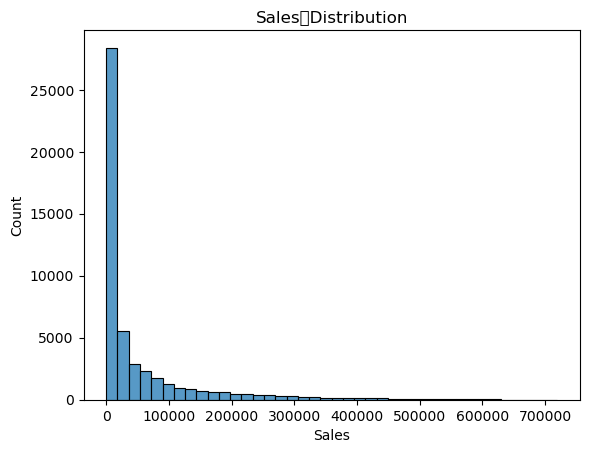

In [40]:
sns.histplot(df["Sales"],	bins=40)
plt.title("Sales	Distribution")
plt.show()

C:\Users\sushil\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


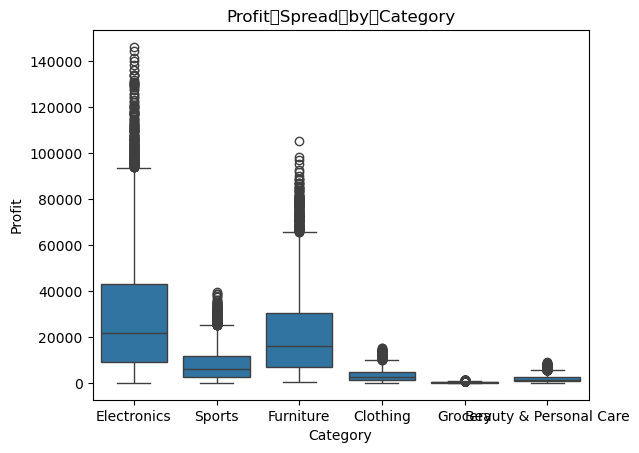

In [41]:
sns.boxplot(x="Category",	y="Profit",	data=df)
plt.title("Profit	Spread	by	Category")
plt.show()

## Step 13 - final validation

In [42]:
df.isnull().sum()		

Order_ID                 0
Order_Date               0
Ship_Date                0
Customer_ID              0
Customer_Name            0
Segment                  0
Region                   0
State                    0
City                     0
Product_ID               0
Category                 0
Sub_Category             0
Quantity                 0
Unit_Price               0
Discount_Percent         0
Sales                    0
Cost                     0
Profit                   0
Ship_Mode                0
Payment_Method           0
Customer_Rating          0
Return_Status            0
Order_Month              0
Delivery_Days            0
Profit_Margin_Percent    0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

## Step 14 - save the cleaned file

In [45]:
df.to_csv("D:/Projects/Retails_Sales_Performance_Analysis/Dataset/cleaned_data.csv",	index=False)